⏳ Вычисляем кластеризацию и строим Heatmap...


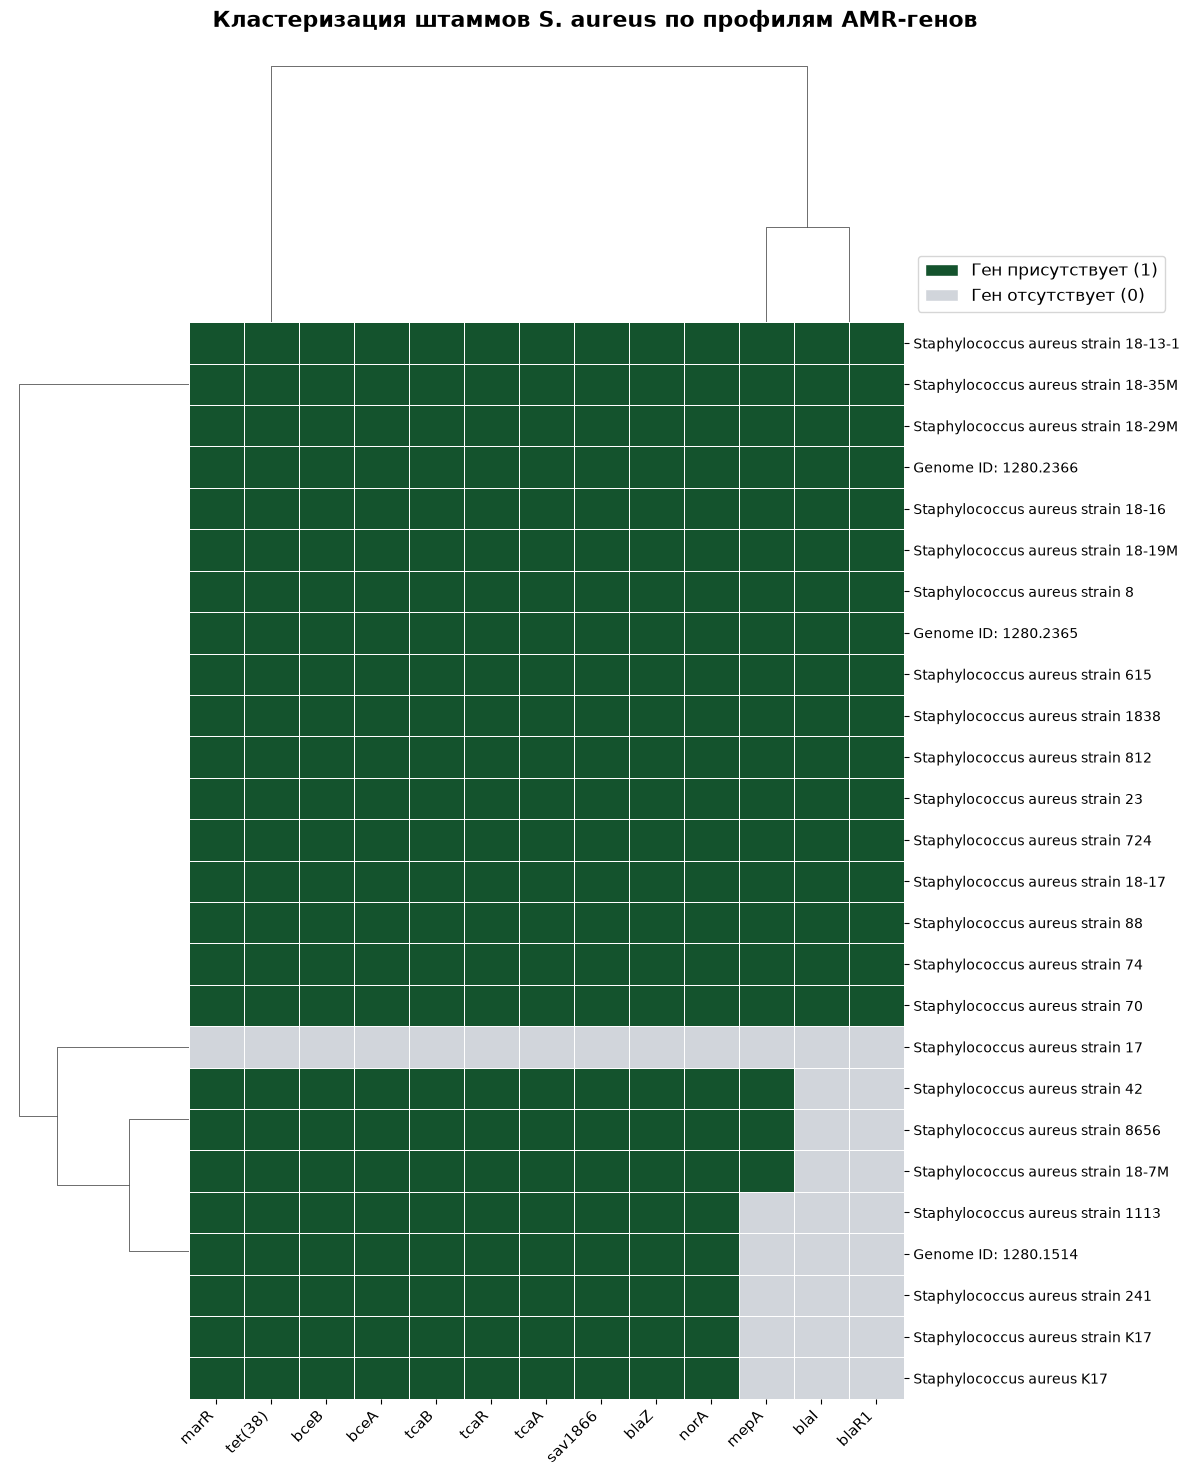

🎉 Визуализация готова и сохранена в: /home/ravenwsl/mastitis_staph_project/results/plots/amr_genes_heatmap.png


In [4]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Настройка путей
BASE_DIR = "/home/ravenwsl/mastitis_staph_project"
OUTPUT_DIR = os.path.join(BASE_DIR, 'data', 'processed')
RESULTS_DIR = os.path.join(BASE_DIR, 'results', 'plots')

# Создаем папку для графиков, если её еще нет
os.makedirs(RESULTS_DIR, exist_ok=True)

# Загружаем матрицу
matrix_output_path = os.path.join(OUTPUT_DIR, "amr_genes_matrix.csv")
metadata_path = os.path.join(OUTPUT_DIR, "combined_metadata.csv")

if not os.path.exists(matrix_output_path):
    print("❌ Матрица amr_genes_matrix.csv не найдена. Сначала запусти скрипт генерации матрицы!")
else:
    # Читаем матрицу (индекс - Genome ID)
    matrix = pd.read_csv(matrix_output_path, index_col=0)
    
    # Читаем метаданные, чтобы заменить ID на красивые названия штаммов
    df_meta = pd.read_csv(metadata_path, dtype={'Genome ID': str})
    id_to_name = dict(zip(df_meta['Genome ID'].astype(str), df_meta['Genome Name']))

    #Если имя штамма nan или отсутствует, заменяем его на Genome ID

    new_index = []
    for gid in matrix.index.astype(str):
        name = id_to_name.get(gid)
        if pd.isna(name) or str(name).strip() == '' or str(name).lower() == 'nan':
            new_index.append(f"Genome ID: {gid}")
        else:
            new_index.append(name)

    
    # Меняем индексы на имена штаммов
    matrix.index = new_index
    
    # 2. Настройка цветовой палитры (0 - серый, 1 - темно-зеленый)
    # Используем цвета: #d1d5db (светло-серый) и #14532d (глубокий темно-зеленый)
    amr_palette = sns.color_palette(["#d1d5db", "#14532d"])
    
    # 3. Построение Clustermap (Heatmap + Дендрограммы)
    print("⏳ Вычисляем кластеризацию и строим Heatmap...")
    
    # Увеличим размер фигуры, чтобы все 26 штаммов и названия генов красиво влезли
    g = sns.clustermap(
        matrix,
        method='ward',          # Метод связи Уорда для построения дендрограммы
        metric='euclidean',     # Евклидово расстояние для бинарных данных
        cmap=amr_palette,       # Наша кастомная палитра цветов
        linewidths=0.5,         # Тонкие линии между ячейками
        linecolor='white',       # Цвет линий разделения
        figsize=(12, 14),       # Размеры графика
        cbar_pos=None,          # Отключаем дефолтную легенду (сделаем красивую свою)
        yticklabels=True,       # Отображать имена штаммов
        xticklabels=True        # Отображать имена генов
    )
    
    # Поворачиваем названия генов горизонтально для читаемости
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=11)
    plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=10)
    
    # Добавляем кастомную легенду вручную
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#14532d', edgecolor='white', label='Ген присутствует (1)'),
        Patch(facecolor='#d1d5db', edgecolor='white', label='Ген отсутствует (0)')
    ]
    g.ax_heatmap.legend(
        handles=legend_elements, 
        loc='lower left', 
        bbox_to_anchor=(1.02, 1.01), 
        borderaxespad=0.,
        fontsize=12
    )
    
    # Добавляем заголовок
    g.fig.suptitle('Кластеризация штаммов S. aureus по профилям AMR-генов', fontsize=16, y=1.02, weight='bold')
    
    # 4. Сохранение графика
    plot_path = os.path.join(RESULTS_DIR, "amr_genes_heatmap.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"🎉 Визуализация готова и сохранена в: {plot_path}")

In [ ]:
import os
import pandas as pd

# 1. Настройка путей относительно корня проекта
BASE_DIR = "/home/ravenwsl/mastitis_staph_project"
RAW_DIR = os.path.join(BASE_DIR, 'data', 'raw')
OUTPUT_DIR = os.path.join(BASE_DIR, 'data', 'processed')

metadata_path = os.path.join(OUTPUT_DIR, "combined_metadata.csv")
features_path = os.path.join(RAW_DIR, "bvbrc_features_table.txt")

# Загружаем метаданные штаммов
df_meta = pd.read_csv(metadata_path, dtype={'Genome ID': str})
genome_ids = df_meta['Genome ID'].unique().tolist()

# Список целевых генов
target_genes = ['blaZ', 'blaI', 'blaR1', 'norA', 'mepA', 'sav1866', 'tcaA', 'tcaR', 'tcaB', 'bceA', 'bceB', 'tet(38)', 'marR']

print(f"📋 Метаданные загружены. Уникальных штаммов для анализа: {len(genome_ids)}")
print("⏳ Чтение и обработка гигантской таблицы функций bvbrc_features_table.txt...")

# 2. Читаем таблицу фичей BV-BRC (разделитель - табуляция)
df_feat = pd.read_csv(features_path, sep='\t', dtype={'Genome ID': str})

# Очищаем названия колонок от случайных пробелов
df_feat.columns = [c.strip() for c in df_feat.columns]

# Фильтруем строки только для наших штаммов
df_feat = df_feat[df_feat['Genome ID'].isin(genome_ids)]
print(f"🧬 Отфильтровано {len(df_feat)} записей белков для твоей группы штаммов.")

# 3. Инициализируем матрицу нулями
matrix = pd.DataFrame(0, index=genome_ids, columns=target_genes)

# Наш точный словарь поисковых маркеров (в нижнем регистре)
gene_keywords = {
    'blaZ': ['lactamase', 'blaz'],
    'blaI': ['blai', 'beta-lactamase operon repressor'],
    'blaR1': ['blar1', 'beta-lactamase regulatory protein'],
    'norA': ['nora', 'quinolone resistance protein nora', 'multidrug efflux pump nora'],
    'mepA': ['mepa', 'multidrug efflux pump mepa'],
    'sav1866': ['sav1866', 'abc transporter', 'multidrug resistance abc transporter'],
    'tcaA': ['tcaa', 'teicoplanin resistance', 'glycopeptide resistance protein tcaa'],
    'tcaR': ['tcar', 'transcriptional regulator tcar', 'transcriptional regulator, marr family'],
    'tcaB': ['tcab', 'teicoplanin resistance'],
    'bceA': ['bcea', 'bacitracin resistance atp-binding protein'],
    'bceB': ['bceb', 'bacitracin resistance permease'],
    'tet(38)': ['tet38', 'tet(38)', 'tetracycline resistance', 'tetracycline efflux'],
    'marR': ['marr', 'transcriptional regulator, marr family']
}

# 4. Заполнение матрицы профилей устойчивости
for _, row in df_feat.iterrows():
    gid = row['Genome ID']
    
    # Извлекаем данные из колонок 'Gene Symbol' и 'Product' (как мы видели на скриншоте)
    gene_symbol = str(row.get('Gene Symbol', '')).lower().strip()
    product_desc = str(row.get('Product', '')).lower().strip()
    
    for gene, keywords in gene_keywords.items():
        if gene_symbol == gene.lower() or any(kw in product_desc for kw in keywords) or any(kw in gene_symbol for kw in keywords):
            matrix.loc[gid, gene] = 1

# 5. Подставляем понятные имена штаммов вместо голых ID для красивого вывода
id_to_name = dict(zip(df_meta['Genome ID'], df_meta['Genome Name']))
matrix_named = matrix.copy()
matrix_named.index = matrix_named.index.map(id_to_name)

# Сохраняем готовую матрицу в CSV
matrix_output_path = os.path.join(OUTPUT_DIR, "amr_genes_matrix.csv")
matrix.to_csv(matrix_output_path)

print("\n🎉 Матрица успешно построена!")
print(f"💾 Файл сохранен в: {matrix_output_path}")
print("📊 Всего обнаружено совпадений генов по всей панели:", matrix.sum().sum())

print("\n👀 Первые 5 строк итоговой матрицы:")
display(matrix_named.head())


📋 Метаданные загружены. Уникальных штаммов для анализа: 26
⏳ Чтение и обработка гигантской таблицы функций bvbrc_features_table.txt...
🧬 Отфильтровано 25 записей белков для твоей группы штаммов.

🎉 Матрица успешно построена!
💾 Файл сохранен в: /home/ravenwsl/mastitis_staph_project/data/processed/amr_genes_matrix.csv
📊 Всего обнаружено совпадений генов по всей панели: 0

👀 Первые 5 строк итоговой матрицы:


,blaZ,blaI,blaR1,norA,mepA,sav1866,tcaA,tcaR,tcaB,bceA,bceB,tet(38),marR
Staphylococcus aureus strain 74,0,0,0,0,0,0,0,0,0,0,0,0,0
Staphylococcus aureus strain 70,0,0,0,0,0,0,0,0,0,0,0,0,0
Staphylococcus aureus strain 88,0,0,0,0,0,0,0,0,0,0,0,0,0
Staphylococcus aureus strain 18-17,0,0,0,0,0,0,0,0,0,0,0,0,0
Staphylococcus aureus strain 724,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
import os
import pandas as pd

# 1. Настройка путей
BASE_DIR = "/home/ravenwsl/mastitis_staph_project"
RAW_DIR = os.path.join(BASE_DIR, 'data', 'raw')
OUTPUT_DIR = os.path.join(BASE_DIR, 'data', 'processed')

metadata_path = os.path.join(OUTPUT_DIR, "combined_metadata.csv")
# Указываем правильное имя нового CSV-файла
features_path = os.path.join(RAW_DIR, "BVBRC_genome_feature.csv")

if not os.path.exists(features_path):
    print(f"❌ Ошибка: Файл {features_path} не найден! Перенеси его в эту папку.")
else:
    # Загружаем метаданные штаммов
    df_meta = pd.read_csv(metadata_path, dtype={'Genome ID': str})
    genome_ids = df_meta['Genome ID'].unique().tolist()
    
    # Список целевых генов
    target_genes = ['blaZ', 'blaI', 'blaR1', 'norA', 'mepA', 'sav1866', 'tcaA', 'tcaR', 'tcaB', 'bceA', 'bceB', 'tet(38)', 'marR']
    
    print(f"📋 Метаданные загружены. Уникальных штаммов для анализа: {len(genome_ids)}")
    print(f"⏳ Чтение и обработка настоящей таблицы функций {os.path.basename(features_path)}...")
    
    # 2. Читаем CSV таблицу (разделитель - запятая)
    df_feat = pd.read_csv(features_path, sep=',', dtype={'Genome ID': str})
    
    # Очищаем названия колонок от случайных пробелов
    df_feat.columns = [c.strip() for c in df_feat.columns]
    
    # Фильтруем строки только для наших штаммов
    df_feat = df_feat[df_feat['Genome ID'].isin(genome_ids)]
    print(f"🧬 Отфильтровано {len(df_feat)} записей белков для твоей группы штаммов.")
    
    # 3. Инициализируем матрицу нулями
    matrix = pd.DataFrame(0, index=genome_ids, columns=target_genes)
    
    # Словарь поисковых маркеров
    gene_keywords = {
        'blaZ': ['lactamase', 'blaz'],
        'blaI': ['blai', 'beta-lactamase operon repressor'],
        'blaR1': ['blar1', 'beta-lactamase regulatory protein'],
        'norA': ['nora', 'quinolone resistance protein nora', 'multidrug efflux pump nora'],
        'mepA': ['mepa', 'multidrug efflux pump mepa'],
        'sav1866': ['sav1866', 'abc transporter', 'multidrug resistance abc transporter'],
        'tcaA': ['tcaa', 'teicoplanin resistance', 'glycopeptide resistance protein tcaa'],
        'tcaR': ['tcar', 'transcriptional regulator tcar', 'transcriptional regulator, marr family'],
        'tcaB': ['tcab', 'teicoplanin resistance'],
        'bceA': ['bcea', 'bacitracin resistance atp-binding protein'],
        'bceB': ['bceb', 'bacitracin resistance permease'],
        'tet(38)': ['tet38', 'tet(38)', 'tetracycline resistance', 'tetracycline efflux'],
        'marR': ['marr', 'transcriptional regulator, marr family']
    }
    
    # 4. Заполнение матрицы
    for _, row in df_feat.iterrows():
        gid = row['Genome ID']
        
        gene_symbol = str(row.get('Gene Symbol', '')).lower().strip()
        product_desc = str(row.get('Product', '')).lower().strip()
        
        for gene, keywords in gene_keywords.items():
            if gene_symbol == gene.lower() or any(kw in product_desc for kw in keywords) or any(kw in gene_symbol for kw in keywords):
                matrix.loc[gid, gene] = 1
                
    # 5. Красивое оформление
    id_to_name = dict(zip(df_meta['Genome ID'], df_meta['Genome Name']))
    matrix_named = matrix.copy()
    matrix_named.index = matrix_named.index.map(id_to_name)
    
    # Сохраняем готовую заполненную матрицу в CSV
    matrix_output_path = os.path.join(OUTPUT_DIR, "amr_genes_matrix.csv")
    matrix.to_csv(matrix_output_path)
    
    print("\n🎉 Матрица успешно построена!")
    print(f"💾 Файл сохранен в: {matrix_output_path}")
    print("📊 Всего обнаружено совпадений генов по всей панели:", matrix.sum().sum())
    
    print("\n👀 Первые 5 строк итоговой матрицы:")
    display(matrix_named.head())

📋 Метаданные загружены. Уникальных штаммов для анализа: 26
⏳ Чтение и обработка настоящей таблицы функций BVBRC_genome_feature.csv...


/tmp/ipykernel_17777/1443315593.py:27: DtypeWarning: Columns (0: FIGfam ID) have mixed types. Specify dtype option on import or set low_memory=False.
  df_feat = pd.read_csv(features_path, sep=',', dtype={'Genome ID': str})


🧬 Отфильтровано 73789 записей белков для твоей группы штаммов.

🎉 Матрица успешно построена!
💾 Файл сохранен в: /home/ravenwsl/mastitis_staph_project/data/processed/amr_genes_matrix.csv
📊 Всего обнаружено совпадений генов по всей панели: 304

👀 Первые 5 строк итоговой матрицы:


,blaZ,blaI,blaR1,norA,mepA,sav1866,tcaA,tcaR,tcaB,bceA,bceB,tet(38),marR
Staphylococcus aureus strain 74,1,1,1,1,1,1,1,1,1,1,1,1,1
Staphylococcus aureus strain 70,1,1,1,1,1,1,1,1,1,1,1,1,1
Staphylococcus aureus strain 88,1,1,1,1,1,1,1,1,1,1,1,1,1
Staphylococcus aureus strain 18-17,1,1,1,1,1,1,1,1,1,1,1,1,1
Staphylococcus aureus strain 724,1,1,1,1,1,1,1,1,1,1,1,1,1


🔬 Анализируем описания функций в FASTA...

📋 ТОП-30 функций белков в твоем FASTA-файле:


hypothetical protein                                                                              543
Uncharacterized MFS-type transporter                                                               18
Oxidoreductase, short-chain dehydrogenase/reductase family                                         10
6-phospho-beta-glucosidase (EC 3.2.1.86)                                                            9
Transcriptional regulator, GntR family                                                              7
ABC transporter, ATP-binding protein                                                                7
Acetyltransferase, GNAT family                                                                      7
Aldehyde dehydrogenase (EC 1.2.1.3)                                                                 6
Phage lysin, N-acetylmuramoyl-L-alanine amidase (EC 3.5.1.28)                                       6
Phosphoglucosamine mutase (EC 5.4.2.10) / Phosphomannomutase (EC 5.4.2.8)         


🔍 Проверка наличия ключевых слов устойчивости:
Слово 'lactamase' встретилось: 2 раз(а)
Слово 'efflux' встретилось: 23 раз(а)
Слово 'resistance' встретилось: 99 раз(а)
Слово 'quinolone' встретилось: 1 раз(а)
Слово 'tetracycline' встретилось: 1 раз(а)
Слово 'repressor' встретилось: 32 раз(а)
